# Mastercard share price prediction

We create different models that try to predict the price of Mastercard shares.

# Data

- Date - date
- Open - opening price
- High - maximum price
- Low - minimum price
- Close - closing price
- Volume - traded amount of shares
- Dividens - Dividends paid
- Stock Splits - A stock split is a situation where a company increases the number of its outstanding shares to increase their liquidity.


We will use the High column for predictions.

# Data retrieval and data analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Let's read the data and throw away the unnecessary columns right away.

In [2]:
dataset = pd.read_csv("..\\dataset\\Mastercard_stock_history.csv", index_col="Date", parse_dates=["Date"]).drop(["Dividends", "Stock Splits"], axis=1)

In [3]:
dataset.head()

,Open,High,Low,Close,Volume
Date,,,,,
2006-05-25,3.748967,4.283869,3.739664,4.279217,395343000
2006-05-26,4.307126,4.348058,4.103398,4.179680,103044000
2006-05-30,4.183400,4.184330,3.986184,4.093164,49898000
2006-05-31,4.125723,4.219679,4.125723,4.180608,30002000
2006-06-01,4.179678,4.474572,4.176887,4.419686,62344000


In [4]:
dataset.describe()

,Open,High,Low,Close,Volume
count,3872.000000,3872.000000,3872.000000,3872.000000,3.872000e+03
mean,104.896814,105.956054,103.769349,104.882714,1.232250e+07
std,106.245511,107.303589,105.050064,106.168693,1.759665e+07
min,3.748967,4.102467,3.739664,4.083861,6.411000e+05
25%,22.347203,22.637997,22.034458,22.300391,3.529475e+06
50%,70.810079,71.375896,70.224002,70.856083,5.891750e+06
75%,147.688448,148.645373,146.822013,147.688438,1.319775e+07
max,392.653890,400.521479,389.747812,394.685730,3.953430e+08


In [5]:
dataset.isna().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Rendering of the share development chart
* We will use 2016 and 2020 data for learning
* We will use data from 2021 for model validation 

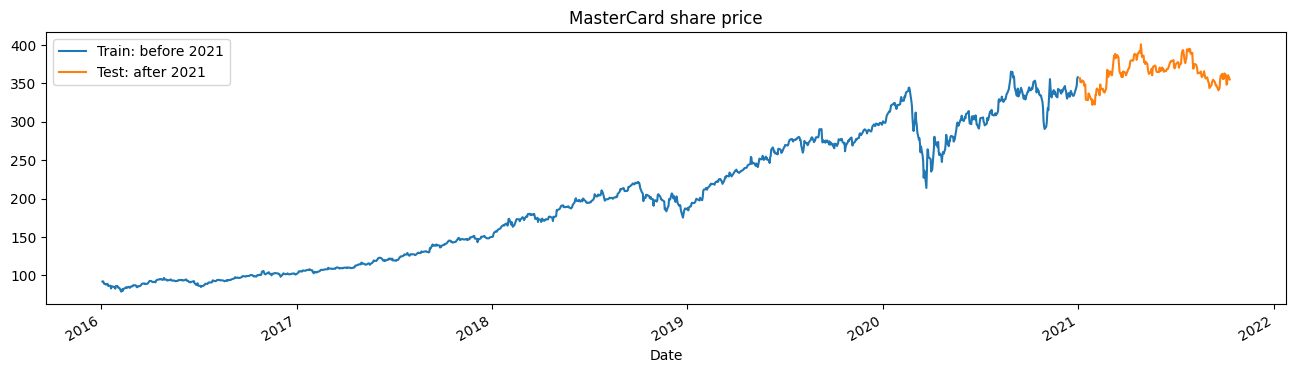

In [17]:
trainig_start = 2016
training_end = 2020

def train_test_plot(dataset, tstart, tend):
    dataset.loc[f"{trainig_start}":f"{training_end}", "High"].plot(figsize=(16, 4), legend=True)
    dataset.loc[f"{training_end + 1}":, "High"].plot(figsize=(16, 4), legend=True)
    plt.legend([f"Train: before {tend+1}", f"Test: after {tend+1}"])
    plt.title("MasterCard share price")
    plt.show()

train_test_plot(dataset,trainig_start,training_end)

# Data preparation

In [11]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

Division of data into training and test data.

- Training data are from 2016 to 2021. 
- Testing data are for 2021.

In [12]:
trainig_start = 2016
training_end = 2020

def train_test_split(dataset, trainig_start, training_end):
    train = dataset.loc[f"{trainig_start}":f"{training_end}", "High"].values
    test = dataset.loc[f"{training_end+1}":, "High"].values
    return train, test

training_data, testing_data = train_test_split(dataset, trainig_start, training_end)

In [13]:
print (f"Training data shape {training_data.shape}")
print (f"Testing data shape {testing_data.shape}")

Training data shape (1259,)
Testing data shape (195,)


Control display of first input data

In [14]:
training_data[0]

np.float64(92.14629263968936)

To standardize the training set, we use the MinMaxScaler function to help us avoid outliers or anomalies. 

You can also try using the StandardScaler function or any other scalar function to normalize the data and improve the model performance.

In [15]:
sc = MinMaxScaler(feature_range=(0, 1))
training_data = training_data.reshape(-1, 1)
training_data_scaled = sc.fit_transform(training_data)

Control display of the first standardized share price

In [16]:
training_data_scaled[0]

array([0.04611702])

The split_sequence function uses the training dataset and converts it into inputs (x_train) and outputs (y_train).

For example, if the sequence is [1,2,3,4,5,6,7,8,9,10,11,12] and n_step is three, then it converts the sequence into three input timestamps and one output.

In [18]:
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


n_steps = 80
features = 1

X_train, y_train = split_sequence(training_data_scaled, n_steps)



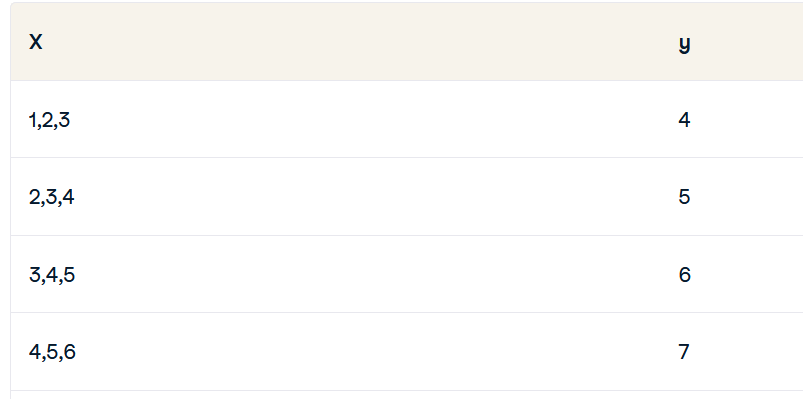

Control matrix shape display

In [19]:
print (X_train.shape)
print (y_train.shape)

(1179, 80, 1)
(1179, 1)


Control display of training data

In [20]:
X_train[0]

array([[0.04611702],
       [0.04692574],
       [0.04271097],
       [0.03589075],
       [0.03545174],
       [0.03160273],
       [0.03420252],
       [0.03514793],
       [0.0335948 ],
       [0.02545779],
       [0.02701094],
       [0.01424825],
       [0.01954913],
       [0.02393842],
       [0.02177754],
       [0.01944783],
       [0.01792852],
       [0.01320159],
       [0.02535648],
       [0.02518764],
       [0.02025819],
       [0.01694932],
       [0.01732071],
       [0.01546385],
       [0.        ],
       [0.00503079],
       [0.01046679],
       [0.00354517],
       [0.01191856],
       [0.01637538],
       [0.01978556],
       [0.01927898],
       [0.01728695],
       [0.02191263],
       [0.02062957],
       [0.01694926],
       [0.01921151],
       [0.02312806],
       [0.02393839],
       [0.02832768],
       [0.02819256],
       [0.02836138],
       [0.02977948],
       [0.02704468],
       [0.02032563],
       [0.0197855 ],
       [0.02181132],
       [0.025

Control display of output data

In [21]:
y_train[0]

array([0.06233366])

We are working with univariate series, so the number of functions is one, and we need to reshape the X_train to fit the LSTM model. 

X_train has [samples, timesteps] and we will transform it to [samples, timesteps, features].

In our case, features = 1

In [22]:
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1],features)

## Preparing training data

In [ ]:
inputs = testing_data
inputs = inputs.reshape(-1, 1)

# standardization
inputs = sc.transform(inputs)

# Splitting data
X_test, y_test = split_sequence(inputs, n_steps)

# Reshape
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], features)

# Simple RNN
The first model will be a simple recurrent neural network.

In [24]:
import keras
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Input

Again, it will be a sequential network.

In [25]:
model_simple = Sequential()

The input data has the following dimensions:
* features = 1, one variable
* n_steps = 80, a series of 80 input values

In [26]:
model_simple.add(Input(shape=(n_steps, features))) 

You can experiment with the number of units, as more units will give you better results. 

* units
* activation

In [27]:
model_simple.add(SimpleRNN(units=125,                          
                           activation="tanh",                 
                           ))  

Then add an output layer that returns a single value.

In [28]:
model_simple.add(Dense(units=1))

Printing of the network structure.

In [29]:
model_simple.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 125)            │        15,875 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,001 (62.50 KB)

 Trainable params: 16,001 (62.50 KB)

 Non-trainable params: 0 (0.00 B)

Setting learning parameters

In [30]:
model_simple.compile(optimizer="RMSprop", loss="mse", metrics=['mae'])

Creating earlystop

In [31]:
early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=30)

## Neural network learning

In [32]:
history_simple=model_simple.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1603 - mae: 0.2404
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0124 - mae: 0.0821
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0041 - mae: 0.0484
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0021 - mae: 0.0318
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 - mae: 0.0233
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.8482e-04 - mae: 0.0203
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.4177e-04 - mae: 0.0184
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.1922e-04 - mae: 0.0199
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.9482e-04 - mae: 0.0177
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.9144e-04 - mae: 0.0175
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.9433e-04 - mae: 0.0184
Epoch 12/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.8256e-04 - mae: 0.0131
Epoch 1

### View learning history

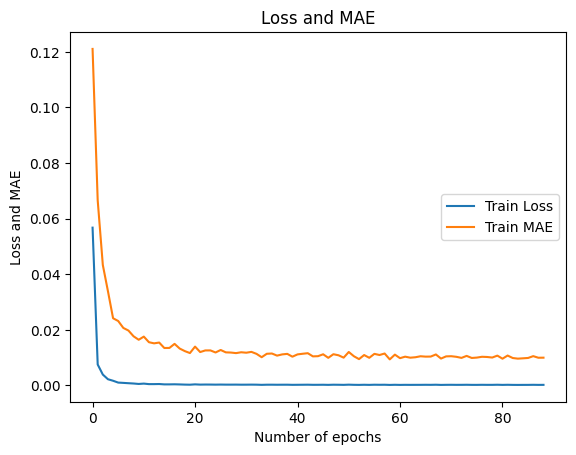

In [33]:
plt.plot(history_simple.history['loss'], label='Train Loss')
plt.plot(history_simple.history['mae'], label='Train MAE')
plt.legend(loc="right")
plt.title('Loss and MAE')
plt.ylabel('Loss and MAE')
plt.xlabel('Number of epochs')
plt.show()

## Model validation

Prediction of future share values

In [58]:
predicted_stock_price = model_simple.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


Inversion of result from standardized value to actual

In [59]:
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

### Chart display

In [60]:
def plot_predictions(test, predicted):
    """ Rendering of predicted and actual action values 
    """
    
    plt.plot(test, color="gray", label="Real")
    plt.plot(predicted, color="red", label="Predicted")
    plt.title("MasterCard Stock Price Prediction")
    plt.xlabel("Time")
    plt.ylabel("MasterCard share price")
    plt.legend()
    plt.show()

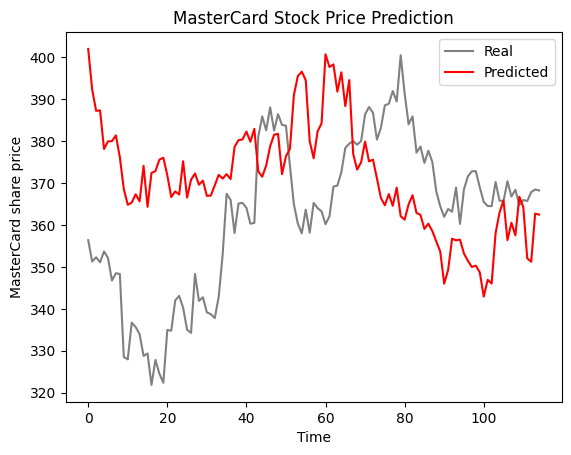

In [61]:
plot_predictions(testing_data[0:y_test.shape[0]], predicted_stock_price)

### RMSE 
Deviations of actual and predicted values. This metric measures absolute difference.

In [62]:
def rmse(test, predicted):    
    return np.sqrt(mean_squared_error(test, predicted))

In [63]:
print("RMSE {:.2f}.".format(rmse(testing_data[0:y_test.shape[0]], predicted_stock_price)))

RMSE 24.53.


#### sMAPE

The sMAPE metric is better for evaluating time series. It is often expressed as a percentage.

sMAPE = mean( |y − ŷ| / (|y| + |ŷ|) )

In [ ]:
# conversion to vectors


In [64]:
import numpy as np

def smape(y_true, y_pred, eps=1e-8):
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(numerator / (denominator + eps)) * 100

In [65]:
print(f"sMAPE: {smape(testing_data[0:y_test.shape[0]], predicted_stock_price):.2f} %")

sMAPE: 5.82 %


#### Directional Accuracy (DA)
Sometimes only the direction matters, not the size. 

In finance, for example, it can indicate whether to buy or sell. 

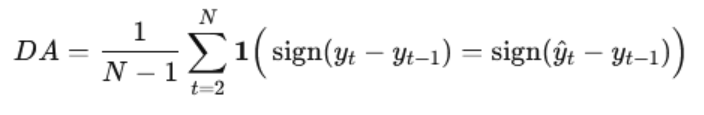

In [ ]:
def directional_accuracy(y_true, y_pred):
    true_diff = y_true[1:] - y_true[:-1]
    pred_diff = y_pred[1:] - y_true[:-1]
    correct_direction = np.sign(true_diff) == np.sign(pred_diff)
    return np.mean(correct_direction)

In [69]:
print(f"Directional Accuracy: {directional_accuracy(testing_data[0:y_test.shape[0]], predicted_stock_price) * 100:.3f} %")

Directional Accuracy: 48.092 %


# LTSM neural network

In [44]:
from keras.layers import Dense, LSTM, GRU, Dropout
from keras.optimizers import SGD

The model consists of one hidden LSTM layer and an output layer. 

You can experiment with the number of units, as more units will give you better results. 

For this experiment, we set the number of LSTM units to 125 as the tanh activation and set the input size.

Finally, we build the model using the RMSprop optimizer and the mean square error as a loss function.

In [45]:
model_ltsm = Sequential()
model_ltsm.add(Input(shape=(n_steps, features))) 
model_ltsm.add(LSTM(units=125, activation="tanh"))
model_ltsm.add(Dense(units=1))

Viewing the network structure.

In [46]:
model_ltsm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 125)            │        63,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,626 (248.54 KB)

 Trainable params: 63,626 (248.54 KB)

 Non-trainable params: 0 (0.00 B)

## Neural network learning

In [47]:
model_ltsm.compile(optimizer="RMSprop", loss="mse", metrics=['mae'])

In [48]:
early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=30)

In [49]:
history_ltsm=model_ltsm.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0352 - mae: 0.1174
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0035 - mae: 0.0435
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0017 - mae: 0.0279
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - mae: 0.0244
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0025 - mae: 0.0348
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0012 - mae: 0.0252
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 9.5841e-04 - mae: 0.0217
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 8.8151e-04 - mae: 0.0192
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 8.4311e-04 - mae: 0.0194
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 8.7978e-04 - mae: 0.0205
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0011 - mae: 0.0244
Epoch 12/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 7.2444e-04 - mae: 0.0185
Epoch

### View learning history

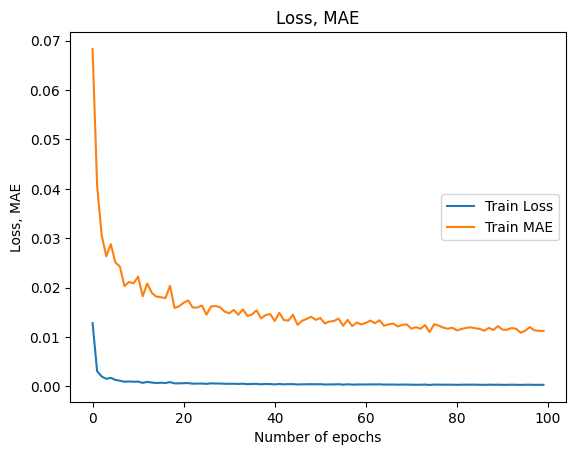

In [50]:
plt.plot(history_ltsm.history['loss'], label='Train Loss')
plt.plot(history_ltsm.history['mae'], label='Train MAE')
plt.legend(loc="right")
plt.title('Loss, MAE')
plt.ylabel('Loss, MAE')
plt.xlabel('Number of epochs')
plt.show()

## Validation of the LTSM model

In [70]:
predicted_stock_price = model_ltsm.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


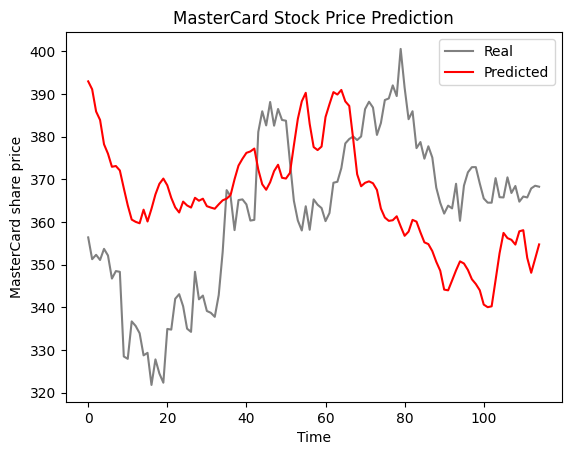

In [71]:
plot_predictions(testing_data[0:y_test.shape[0]], predicted_stock_price)

In [72]:
print("RMSE {:.2f}.".format(rmse(testing_data[0:y_test.shape[0]], predicted_stock_price)))

RMSE 23.00.


In [73]:
print(f"sMAPE: {smape(testing_data[0:y_test.shape[0]], predicted_stock_price):.2f} %")

sMAPE: 5.80 %


In [74]:
print(f"Directional Accuracy: {directional_accuracy(testing_data[0:y_test.shape[0]], predicted_stock_price) * 100:.3f} %")

Directional Accuracy: 48.784 %


# Model GRU
Model based on Gated Recurrent Unit.

In [75]:
model_gru = Sequential()
model_gru.add(Input(shape=(n_steps, features))) 
model_gru.add(GRU(units=125, activation="tanh"))
model_gru.add(Dense(units=1))

Viewing the network structure

In [76]:
model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 125)            │        48,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,126 (187.99 KB)

 Trainable params: 48,126 (187.99 KB)

 Non-trainable params: 0 (0.00 B)

## Neural network training

In [77]:
model_gru.compile(optimizer="RMSprop", loss="mse", metrics=['mae'])
early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=30)

In [78]:
history_gru=model_gru.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0458 - mae: 0.1272
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0014 - mae: 0.0246
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0016 - mae: 0.0306
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0012 - mae: 0.0259
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 8.5150e-04 - mae: 0.0186
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 9.7630e-04 - mae: 0.0208
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 8.8448e-04 - mae: 0.0210
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.6110e-04 - mae: 0.0180
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0011 - mae: 0.0253
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 9.0842e-04 - mae: 0.0222
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.7160e-04 - mae: 0.0168
Epoch 12/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.6455e-04 - mae: 0.01

### View learning history

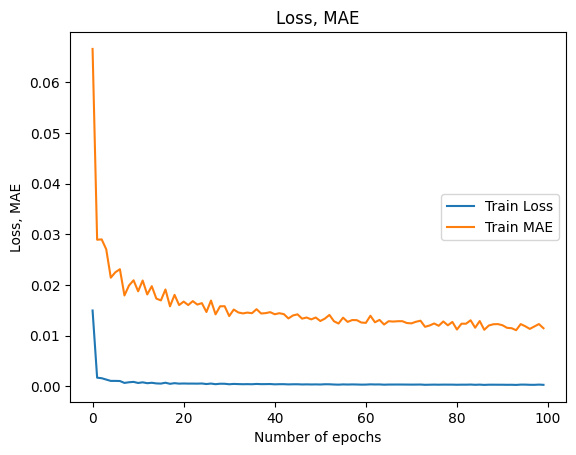

In [80]:
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['mae'], label='Train MAE')
plt.legend(loc="right")
plt.title('Loss, MAE')
plt.ylabel('Loss, MAE')
plt.xlabel('Number of epochs')
plt.show()

## Validation

In [81]:
predicted_stock_price = model_gru.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


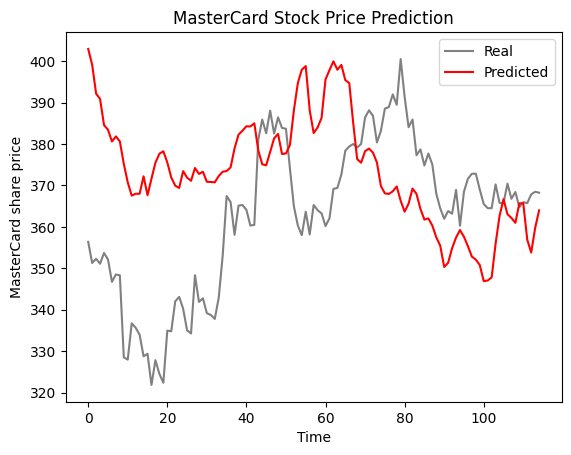

In [82]:
plot_predictions(testing_data[0:y_test.shape[0]], predicted_stock_price)

In [83]:
print("RMSE {:.2f}.".format(rmse(testing_data[0:y_test.shape[0]], predicted_stock_price)))

RMSE 25.44.


In [84]:
print(f"sMAPE: {smape(testing_data[0:y_test.shape[0]], predicted_stock_price):.2f} %")

sMAPE: 5.89 %


In [85]:
print(f"Directional Accuracy: {directional_accuracy(testing_data[0:y_test.shape[0]], predicted_stock_price) * 100:.3f} %")

Directional Accuracy: 47.992 %
